In [8]:
!pip -q install kagglehub

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [9]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path: /kaggle/input/chest-xray-pneumonia


In [10]:
dataset_root = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "test")
val_dir = os.path.join(dataset_root, "val")

print("Train:", train_dir)
print("Test :", test_dir)
print("Val  :", val_dir)

Train: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test : /kaggle/input/chest-xray-pneumonia/chest_xray/test
Val  : /kaggle/input/chest-xray-pneumonia/chest_xray/val


In [11]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_data = test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


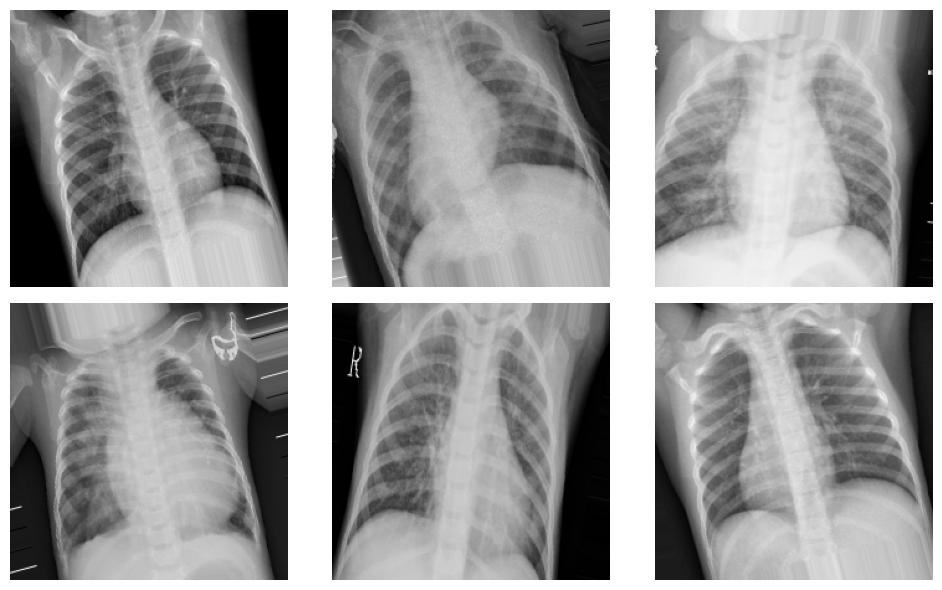

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 865ms/step - accuracy: 0.8850 - loss: 0.2619 - val_accuracy: 0.8125 - val_loss: 0.3869
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.9281 - loss: 0.1732 - val_accuracy: 0.8750 - val_loss: 0.2629
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.9304 - loss: 0.1622 - val_accuracy: 0.8125 - val_loss: 0.3264
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9419 - loss: 0.1470 - val_accuracy: 0.8750 - val_loss: 0.2715
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 638ms/step - accuracy: 0.9452 - loss: 0.1391 - val_accuracy: 0.8125 - val_loss: 0.3599


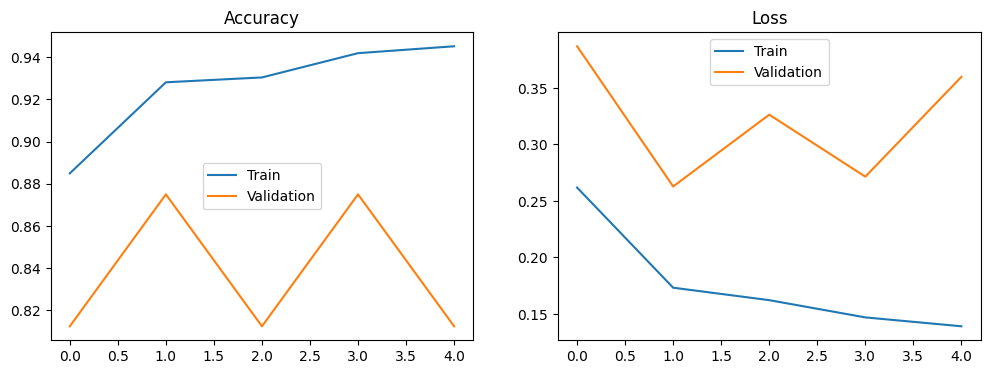

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

In [17]:
pred_prob = model.predict(test_data)

predicted = (pred_prob > 0.5).astype(int).flatten()

true_labels = test_data.classes

precision = precision_score(true_labels, predicted)
recall = recall_score(true_labels, predicted)
f1 = f1_score(true_labels, predicted)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 651ms/step
Precision : 0.8370
Recall    : 0.9872
F1 Score  : 0.9059


In [18]:
pred_prob = model.predict(test_data)

predicted = (pred_prob > 0.5).astype(int).flatten()

true_labels = test_data.classes

precision = precision_score(true_labels, predicted)
recall = recall_score(true_labels, predicted)
f1 = f1_score(true_labels, predicted)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step
Precision : 0.8370
Recall    : 0.9872
F1 Score  : 0.9059


In [19]:
print(classification_report(
    true_labels,
    predicted,
    target_names=['NORMAL','PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.68      0.80       234
   PNEUMONIA       0.84      0.99      0.91       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.89      0.87      0.87       624



/tmp/ipykernel_3287/4222932128.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = int(prediction[0] > 0.5)


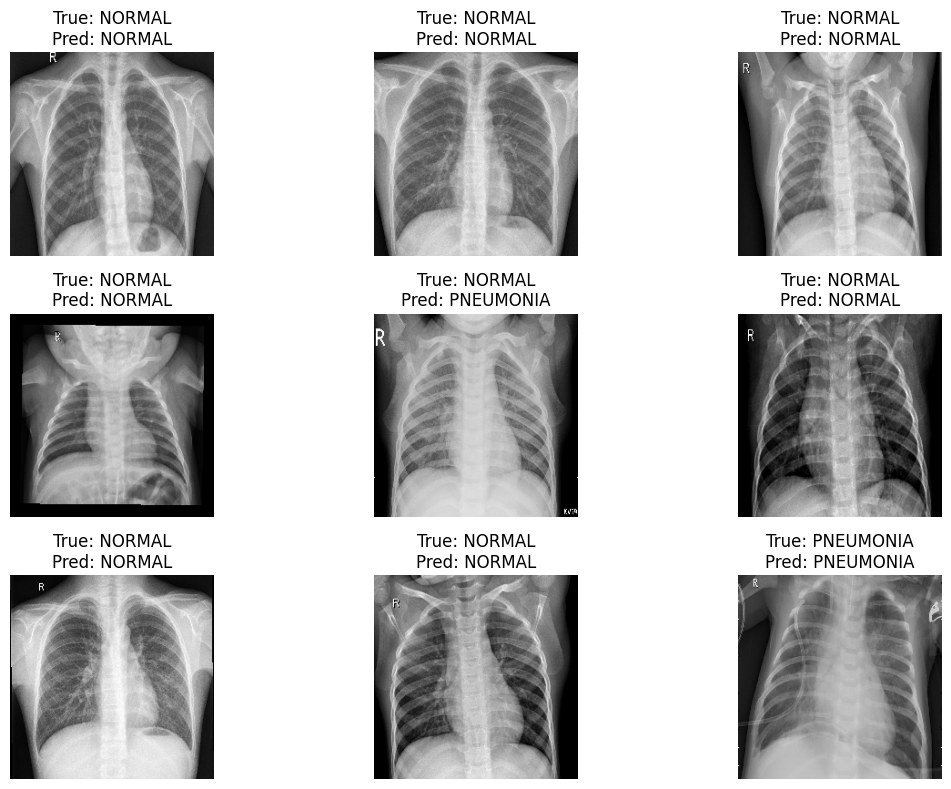

In [20]:
class_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(12,8))

for i in range(9):

    img = test_data[i][0][0]
    true_label = int(test_data[i][1][0])

    prediction = model.predict(
        np.expand_dims(img, axis=0),
        verbose=0
    )

    pred_label = int(prediction[0] > 0.5)

    plt.subplot(3,3,i+1)
    plt.imshow(img)

    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()